# Generative Adversarial Networks (GANs) ด้วย PyTorch
Generative Adversarial Networks (GANs) ได้เปลี่ยนแปลงวงการการเรียนรู้ของเครื่อง (Machine Learning) โดยอนุญาตให้สร้างตัวอย่างข้อมูลที่สมจริง เช่น รูปภาพ ที่ไม่สามารถแยกแยะความแตกต่างจากข้อมูลจริงได้

## Outline
1. ภาพรวมของ GANs
2. ทฤษฎีพื้นฐานเชิงสัญญาณ
3. การตั้งค่าเริ่มต้นสภาพแวดล้อม
4. การสร้าง GAN ใน PyTorch
 1. การนำเข้าไลบรารี
 2. การเตรียมชุดข้อมูล
 3. การกำหนด Generator
 4. การกำหนด Discriminator
 5. การตั้งค่าพารามิเตอร์การฝึก
 6. การฝึก GAN
 7. การแสดงผลลัพธ์
5. สรุป
6. อ้างอิง

# 1. ภาพรวมของ GANs
 * Generative Adversarial Networks (GANs) เป็นกรอบงานการเรียนรู้ของเครื่องประเภทหนึ่งที่ออกแบบโดย Ian Goodfellow และเพื่อนร่วมงานในปี 2014
 * GANs ประกอบด้วยเครือข่ายประสาทสองตัว—Generator และ Discriminator—ซึ่งถูกฝึกพร้อมกันผ่านกระบวนการการแข่งขัน
 * Generator สร้างตัวอย่างข้อมูล ในขณะที่ Discriminator ประเมินและเปรียบเทียบกับข้อมูลจริงเพื่อให้ข้อมูลย้อนกลับสำหรับการปรับปรุง Generator

# 2. ทฤษฎีพื้นฐาน
1. ส่วนประกอบของ GANs
 * Generator (G): รับสัญญาณสุ่มเป็นอินพุตและสร้างตัวอย่างข้อมูล (เช่น รูปภาพ) โดยมีเป้าหมายในการเลียนแบบการแจกแจงข้อมูลจริง
 * Discriminator (D): รับทั้งตัวอย่างข้อมูลจริงและตัวอย่างข้อมูลที่ Generator สร้างขึ้น และพยายามแยกแยะข้อมูลจริงจากข้อมูลปลอม โดยให้ค่าความน่าจะเป็นที่ข้อมูลนั้นจะเป็นของจริง

2. กระบวนการการแข่งขัน

 * วัตถุประสงค์ในการฝึก:
    * Generator: ต้องการสร้างข้อมูลที่ Discriminator ไม่สามารถแยกแยะได้ว่าข้อมูลนั้นเป็นของจริงหรือปลอม
    * Discriminator: ต้องการจำแนกข้อมูลจริงจากข้อมูลปลอมได้อย่างแม่นยำ

 * มุมมองเชิงเกมทฤษฎี:
    * GANs ถูกฝึกโดยใช้เกมแบบ minimax ที่ G พยายามเพิ่มความน่าจะเป็นที่ D จะทำผิดพลาด
    * ขณะที่ D พยายามลดความน่าจะเป็นนี้


3. ฟังก์ชันค่าเสียหาย (Loss Functions)
 * Discriminator Loss: วัดความสามารถของ D ในการแยกแยะข้อมูลจริงจากข้อมูลปลอม
$${L}_D = -\left(\mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]\right)$$

 * Generator Loss: วัดความสามารถของ G ในการหลอก D
$${L}_G = -\mathbb{E}_{z \sim p_z}[\log D(G(z))]$$

 * การฝึกจะสลับกันระหว่างการลดค่า ${L}_D$ สำหรับ D และการลดค่า ${L}_G$ สำหรับ G

4. การฝึก
 * ในช่วงเริ่มต้น, G จะสร้างข้อมูลสุ่มที่ D สามารถจำแนกเป็นปลอมได้ง่าย
 * เมื่อการฝึกดำเนินไป, G จะพัฒนาขึ้นในการสร้างข้อมูลที่สมจริง ทำให้ D ยากต่อการแยกแยะข้อมูลจริงจากข้อมูลปลอม
 * จะเกิดสมดุลขึ้นเมื่อ D ไม่สามารถแยกแยะข้อมูลจริงจากข้อมูลปลอมได้ดีกว่าการสุ่ม (เช่น D ให้ค่า 0.5 สำหรับทุกอินพุต)

5. ความท้าทายในการฝึก GANs
 * Mode Collapse: G อาจสร้างผลลัพธ์ที่มีความหลากหลายจำกัด
 * Non-convergence: D และ G อาจไม่สามารถเรียรู้ถึงจุดสมดุลได้
 * Vanishing Gradients: ถ้า D เก่งเกินไป, G อาจได้รับข้อมูล feedback ไม่เพียงพอ



# 3. การเตรียมสถาพแวดล้อม
สามารถติดตั้งไลบรารีที่จำเป็นโดยใช้
```bash
pip install torch torchvision numpy matplotlib
```

หรือหากใช้ Anaconda:
```bash
conda install pytorch torchvision -c pytorch
conda install numpy matplotlib
```

# 4. การสร้าง GAN ใน PyTorch
เราจะเดินผ่านการสร้าง GAN แบบง่ายที่สามารถสร้างตัวเลขเขียนมือที่คล้ายกับชุดข้อมูล MNIST


4.1. การนำเข้าไลบรารี:
เริ่มต้นด้วยการนำเข้าไลบรารีที่จำเป็น

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

4.2. การเตรียมชุดข้อมูล:

ในที่นี้จะใช้ชุดข้อมูล MNIST ซึ่งประกอบด้วยรูปภาพเกรย์สเกลขนาด 28x28 ของตัวเลขเขียนมือ

In [ ]:
# กำหนดการแปลงข้อมูล: นอร์มัลไลซ์รูปภาพให้อยู่ในช่วง [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ดาวน์โหลดและเตรียมชุดข้อมูล MNIST
train_dataset = datasets.MNIST(root='mnist_data/', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:10<00:00, 909kB/s] 


Extracting mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]


Extracting mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]

Extracting mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist_data/MNIST/raw



4.3. การกำหนด Generator:

เครือข่าย Generator รับสัญญาณสุ่มและแปลงเป็นตัวอย่างข้อมูลที่คล้ายกับข้อมูลจริง

In [ ]:
class Generator(nn.Module):
    def __init__(self, input_dim=100, output_dim=784):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, output_dim),
            nn.Tanh()  # เอาต์พุตอยู่ในช่วง [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

4.4. การกำหนด Discriminator

เครือข่าย Discriminator ประเมินตัวอย่างข้อมูลและให้ค่าความน่าจะเป็นที่ข้อมูลนั้นเป็นของจริง

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_dim=784):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # เอาต์พุตเป็นความน่าจะเป็นระหว่าง [0,1]
        )

    def forward(self, x):
        return self.net(x)

4.5. การตั้งค่าพารามิเตอร์การฝึก

เริ่มต้นโมเดล, กำหนดฟังก์ชันค่าเสียหายและตัวปรับแต่ง

In [ ]:
# เริ่มต้น Generator และ Discriminator
G = Generator()
D = Discriminator()

# ใช้ GPU ถ้ามี
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G.to(device)
D.to(device)

# ฟังก์ชันค่าเสียหาย
criterion = nn.BCELoss()

# ตัวปรับแต่ง
lr = 0.0002
G_optimizer = optim.Adam(G.parameters(), lr=lr)
D_optimizer = optim.Adam(D.parameters(), lr=lr)


4.6. การฝึก GAN

เราจะฝึก GAN เป็นจำนวน epoch ที่กำหนด โดยอัปเดต Discriminator และ Generator ในแต่ละรอบ

Epoch [1/50]  D_loss: 0.2587  G_loss: 4.1948


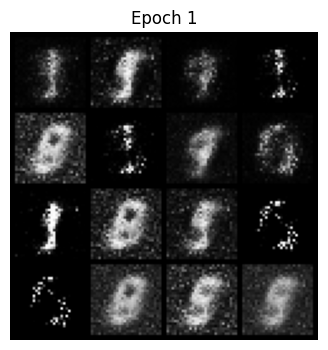

Epoch [2/50]  D_loss: 0.3773  G_loss: 2.9062
Epoch [3/50]  D_loss: 0.4344  G_loss: 3.3936
Epoch [4/50]  D_loss: 0.4104  G_loss: 3.3096
Epoch [5/50]  D_loss: 0.3835  G_loss: 2.9863
Epoch [6/50]  D_loss: 0.4042  G_loss: 2.3635
Epoch [7/50]  D_loss: 0.8134  G_loss: 2.1219
Epoch [8/50]  D_loss: 0.6432  G_loss: 2.1066
Epoch [9/50]  D_loss: 0.7017  G_loss: 2.5985
Epoch [10/50]  D_loss: 0.4173  G_loss: 2.6691


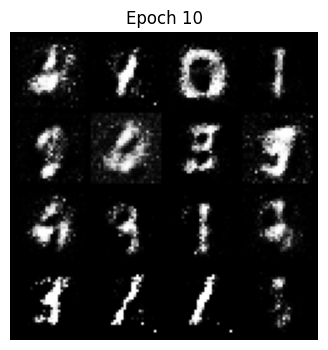

Epoch [11/50]  D_loss: 0.6938  G_loss: 2.5720
Epoch [12/50]  D_loss: 0.9649  G_loss: 1.7328
Epoch [13/50]  D_loss: 0.7651  G_loss: 2.3066
Epoch [14/50]  D_loss: 0.5869  G_loss: 2.5299
Epoch [15/50]  D_loss: 0.9105  G_loss: 2.0440
Epoch [16/50]  D_loss: 0.7469  G_loss: 1.9419
Epoch [17/50]  D_loss: 0.7319  G_loss: 1.9929
Epoch [18/50]  D_loss: 0.9248  G_loss: 1.6511
Epoch [19/50]  D_loss: 0.9887  G_loss: 1.8574
Epoch [20/50]  D_loss: 0.5461  G_loss: 2.3190


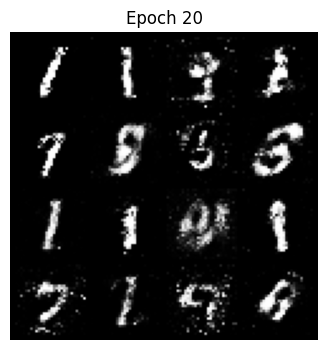

Epoch [21/50]  D_loss: 1.1941  G_loss: 1.3603
Epoch [22/50]  D_loss: 0.9649  G_loss: 1.5897
Epoch [23/50]  D_loss: 0.9573  G_loss: 1.8829
Epoch [24/50]  D_loss: 0.8791  G_loss: 2.0997
Epoch [25/50]  D_loss: 0.9592  G_loss: 1.3207
Epoch [26/50]  D_loss: 0.8856  G_loss: 1.3843
Epoch [27/50]  D_loss: 0.7719  G_loss: 1.6420
Epoch [28/50]  D_loss: 1.2289  G_loss: 1.3286
Epoch [29/50]  D_loss: 0.9969  G_loss: 1.5440
Epoch [30/50]  D_loss: 1.0563  G_loss: 1.2250


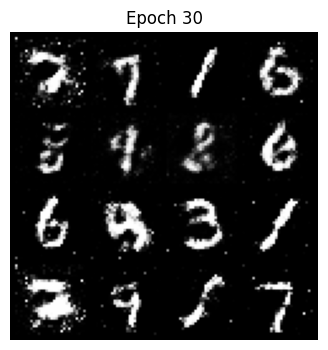

Epoch [31/50]  D_loss: 0.9794  G_loss: 1.2835
Epoch [32/50]  D_loss: 1.1077  G_loss: 1.3787
Epoch [33/50]  D_loss: 0.8784  G_loss: 1.4107
Epoch [34/50]  D_loss: 1.0402  G_loss: 1.2872
Epoch [35/50]  D_loss: 0.8965  G_loss: 1.3707
Epoch [36/50]  D_loss: 1.3095  G_loss: 1.1228
Epoch [37/50]  D_loss: 0.9355  G_loss: 1.6227
Epoch [38/50]  D_loss: 1.0103  G_loss: 1.3420
Epoch [39/50]  D_loss: 0.9047  G_loss: 1.5525
Epoch [40/50]  D_loss: 1.0493  G_loss: 1.2510


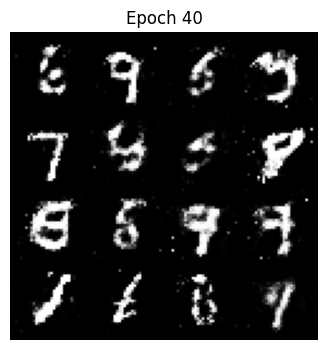

Epoch [41/50]  D_loss: 0.9127  G_loss: 1.4261
Epoch [42/50]  D_loss: 1.1261  G_loss: 1.3426
Epoch [43/50]  D_loss: 0.9377  G_loss: 1.2982
Epoch [44/50]  D_loss: 0.9597  G_loss: 1.5192
Epoch [45/50]  D_loss: 1.1453  G_loss: 1.3308
Epoch [46/50]  D_loss: 1.0465  G_loss: 1.0049
Epoch [47/50]  D_loss: 0.9728  G_loss: 1.1635
Epoch [48/50]  D_loss: 1.1833  G_loss: 1.2047
Epoch [49/50]  D_loss: 0.9525  G_loss: 1.3672
Epoch [50/50]  D_loss: 1.1725  G_loss: 1.0999


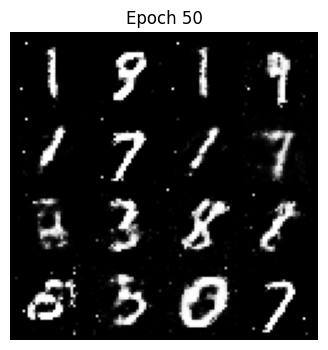

In [ ]:
# พารามิเตอร์การฝึก
num_epochs = 50
latent_dim = 100
sample_interval = 10  # บันทึกตัวอย่างทุก 10 epoch

# รายการเก็บค่าเสียหายสำหรับการวาดกราฟ
G_losses = []
D_losses = []

for epoch in range(1, num_epochs+1):
    for batch_idx, (real_data, _) in enumerate(train_loader):
        real_data = real_data.view(-1, 784).to(device)

        # ป้ายกำกับสำหรับข้อมูลจริงและปลอม
        real_labels = torch.ones(real_data.size(0), 1).to(device)
        fake_labels = torch.zeros(real_data.size(0), 1).to(device)

        ## ฝึก Discriminator
        D_optimizer.zero_grad()

        # ข้อมูลจริง
        outputs = D(real_data)
        D_real_loss = criterion(outputs, real_labels)

        # ข้อมูลปลอม
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G(z)
        outputs = D(fake_data.detach())  # Detach เพื่อไม่ให้ฝึก G บนป้ายกำกับเหล่านี้
        D_fake_loss = criterion(outputs, fake_labels)

        # ค่าเสียหายรวมของ Discriminator
        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optimizer.step()

        ## ฝึก Generator
        G_optimizer.zero_grad()

        # สร้างข้อมูลปลอมและพยายามหลอก Discriminator
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G(z)
        outputs = D(fake_data)
        G_loss = criterion(outputs, real_labels)  # เราต้องการให้ D เชื่อว่าข้อมูลปลอมเป็นจริง

        G_loss.backward()
        G_optimizer.step()

        # บันทึกค่าความเสียหายสำหรับการวาดกราฟ
        G_losses.append(G_loss.item())
        D_losses.append(D_loss.item())

    # แสดงความคืบหน้า
    print(f"Epoch [{epoch}/{num_epochs}]  D_loss: {D_loss.item():.4f}  G_loss: {G_loss.item():.4f}")

    # บันทึกรูปตัวอย่าง
    if epoch % sample_interval == 0 or epoch == 1:
        with torch.no_grad():
            z = torch.randn(16, latent_dim).to(device)
            sample = G(z).cpu().view(-1, 1, 28, 28)
            grid = torchvision.utils.make_grid(sample, nrow=4, normalize=True)
            np_grid = grid.numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(np_grid, (1,2,0)))
            plt.title(f'Epoch {epoch}')
            plt.axis('off')
            plt.show()


4.7. การแสดงผลลัพธ์

หลังจากการฝึกเสร็จสิ้น, สามารถแสดงกราฟค่าความเสียหายเพื่อประเมินการฝึกได้

นอกจากนี้, ยังสามารถสร้างตัวอย่างใหม่เพื่อดูว่า Generator ได้เรียนรู้ในการสร้างข้อมูลที่สมจริงได้ดีเพียงใด

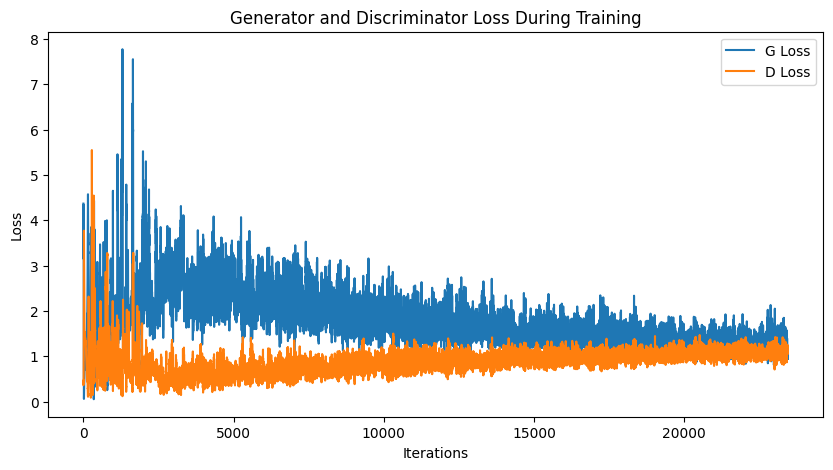

In [ ]:
# วาดกราฟ loss
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

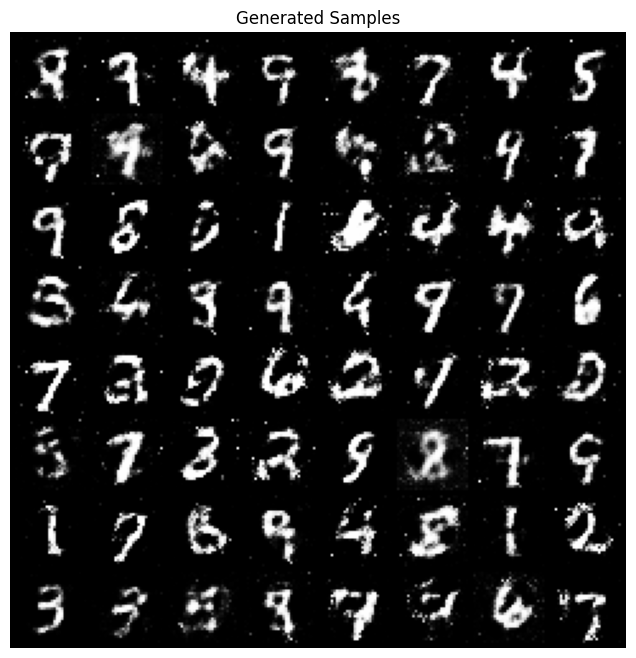

In [ ]:
# สร้างตัวอย่างใหม่
with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated_samples = G(z).cpu().view(-1, 1, 28, 28)
    grid = torchvision.utils.make_grid(generated_samples, nrow=8, normalize=True)
    np_grid = grid.numpy()
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(np_grid, (1,2,0)))
    plt.title("Generated Samples")
    plt.axis('off')
    plt.show()


# สรุป
ในหัวข้อนี้เป็นพื้นฐานของ Generative Adversarial Networks (GANs) และวิธีการประยุกต์ใช้ด้วย PyTorch โดยเข้าใจบทบาทของ Generator และ Discriminator และกระบวนการฝึกแบบแข่งขัน * เราสามารถสร้างโมเดลที่สร้างตัวอย่างข้อมูลที่สมจริงได้

GANs มีแอปพลิเคชันที่หลากหลาย รวมถึงการสร้างภาพ, การเพิ่มข้อมูล, และงานที่ซับซ้อนยิ่งขึ้นเช่นการแปลงภาพไปยังภาพ และการโอนสไตล์

# อ้างอิง
* เอกสาร GAN ดั้งเดิม: Goodfellow, I., et al. "Generative adversarial nets." Advances in neural information processing systems. 2014.
* เอกสารทางการของ PyTorch: https://pytorch.org/docs/stable/index.html
* Introduction to GAN ของ PyTorch: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
* คู่มือ GAN ของ Google Developers: https://developers.google.com/machine-learning/gan

Lab12

จาก Introduction to GAN ของ PyTorch: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

ให้นักศึกษาทดลองเพิ่ม attention module ให้กับโมเดลตัวอย่างแล้วเปรียบเทียบผลของการสร้างภาพของ Generator

โดยโหลดข้อมูลด้วยคำสั่งที่เตรียมไว้ให้นี้

```
!gdown 1wcZ0fAvfAirv5stZAn5yOdGwExBg769p
!mkdir data
!mkdir data/celeba
!unzip -q img_align_celeba_small.zip -d /content/data/celeba
```

